# Binary Health Classifier — Corrected GAI

We evaluate whether corrected GAI can discriminate healthy vs non-healthy individuals,
using two methods (direct threshold and logistic regression) across **all output folders**
(two datasets × with/without age-band fix).

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

pd.set_option("display.precision", 2)

## Discover output folders

We scan `my_output/` for subdirectories that contain a `result.tsv` file.

In [33]:
output_root = "my_output"
output_dirs = sorted([
    d for d in os.listdir(output_root)
    if os.path.isfile(os.path.join(output_root, d, "result.tsv"))
])
print(f"Found {len(output_dirs)} output folders with result.tsv:")
for d in output_dirs:
    print(f"  {d}")

Found 4 output folders with result.tsv:
  AGP
  AGP-agefix
  GGMP
  GGMP-agefix


## Helper functions

These are used in the per-folder analysis loop below.

In [34]:
def fold_metrics_from_labels(y_true, y_pred):
    """Balanced accuracy, sensitivity, specificity from binary labels."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return {"ba": balanced_accuracy_score(y_true, y_pred), "sensitivity": sens, "specificity": spec}


def mean_std(metrics_list, key):
    vals = np.array([m[key] for m in metrics_list], dtype=float)
    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1))

In [35]:
def analyse_folder(name, output_root="my_output"):
    """Run the full binary classification analysis for one output folder.

    Returns a dict with all metrics and intermediate arrays needed for plotting.
    """
    result_path = os.path.join(output_root, name, "result.tsv")
    age_results_df = pd.read_csv(result_path, sep="\t")

    # Prepare analysis data
    analysis_df = age_results_df[["health", "corrected GAI"]].copy()
    analysis_df = analysis_df.dropna(subset=["corrected GAI", "health"]).copy()
    analysis_df["y"] = (analysis_df["health"] == "n").astype(int)

    n_total = len(age_results_df)
    n_used = len(analysis_df)

    healthy_vals = analysis_df.loc[analysis_df["y"] == 0, "corrected GAI"].to_numpy()
    nonhealthy_vals = analysis_df.loc[analysis_df["y"] == 1, "corrected GAI"].to_numpy()

    # Significance test
    u_stat, p_value = mannwhitneyu(nonhealthy_vals, healthy_vals, alternative="two-sided")
    rank_biserial = (2 * u_stat) / (len(nonhealthy_vals) * len(healthy_vals)) - 1

    # Summary table
    summary = analysis_df.groupby("y")["corrected GAI"].agg(["count", "mean", "median", "std", "min", "max"])
    summary.index = ["healthy (0)", "non-healthy (1)"]

    X = analysis_df["corrected GAI"].to_numpy()
    y = analysis_df["y"].to_numpy()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # --- Method A: direct corrected GAI threshold ---
    direction = 1.0 if nonhealthy_vals.mean() >= healthy_vals.mean() else -1.0
    X_direct_score = direction * X
    thr_direct = np.linspace(X_direct_score.min(), X_direct_score.max(), 201)
    mean_ba_direct = []
    for t in thr_direct:
        fold_bas = [
            balanced_accuracy_score(y[ti], (X_direct_score[ti] >= t).astype(int))
            for _, ti in cv.split(X.reshape(-1, 1), y)
        ]
        mean_ba_direct.append(np.mean(fold_bas))

    best_thr_direct = float(thr_direct[int(np.argmax(mean_ba_direct))])

    direct_fold_metrics, direct_fold_aucs = [], []
    direct_oof_scores = np.zeros_like(X, dtype=float)
    for _, ti in cv.split(X.reshape(-1, 1), y):
        sv = X_direct_score[ti]
        pv = (sv >= best_thr_direct).astype(int)
        direct_fold_metrics.append(fold_metrics_from_labels(y[ti], pv))
        direct_fold_aucs.append(roc_auc_score(y[ti], sv))
        direct_oof_scores[ti] = sv

    best_thr_direct_gai = best_thr_direct / direction

    # --- Method B: logistic regression + probability threshold ---
    thr_prob = np.linspace(0, 1, 201)
    mean_ba_prob = []
    for t in thr_prob:
        fold_bas = []
        for tri, tei in cv.split(X.reshape(-1, 1), y):
            lr = LogisticRegression(solver="lbfgs", max_iter=1000)
            lr.fit(X[tri].reshape(-1, 1), y[tri])
            prob = lr.predict_proba(X[tei].reshape(-1, 1))[:, 1]
            fold_bas.append(balanced_accuracy_score(y[tei], (prob >= t).astype(int)))
        mean_ba_prob.append(np.mean(fold_bas))

    best_thr_prob = float(thr_prob[int(np.argmax(mean_ba_prob))])

    logit_fold_metrics, logit_fold_aucs = [], []
    logit_oof_probs = np.zeros_like(X, dtype=float)
    coef_vals, intercept_vals = [], []
    for tri, tei in cv.split(X.reshape(-1, 1), y):
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(X[tri].reshape(-1, 1), y[tri])
        prob = lr.predict_proba(X[tei].reshape(-1, 1))[:, 1]
        logit_fold_metrics.append(fold_metrics_from_labels(y[tei], (prob >= best_thr_prob).astype(int)))
        logit_fold_aucs.append(roc_auc_score(y[tei], prob))
        logit_oof_probs[tei] = prob
        coef_vals.append(lr.coef_[0, 0])
        intercept_vals.append(lr.intercept_[0])

    # --- Build comparison rows ---
    rows = []
    for label, fm, fa in [("A: direct GAI threshold", direct_fold_metrics, direct_fold_aucs),
                           ("B: logistic + prob threshold", logit_fold_metrics, logit_fold_aucs)]:
        ba_m, ba_s = mean_std(fm, "ba")
        sens_m, _ = mean_std(fm, "sensitivity")
        spec_m, _ = mean_std(fm, "specificity")
        rows.append({
            "method": label,
            "best_threshold": best_thr_direct_gai if "direct" in label else best_thr_prob,
            "balanced_accuracy_mean": ba_m, "balanced_accuracy_std": ba_s,
            "auc_mean": float(np.mean(fa)), "auc_std": float(np.std(fa, ddof=1)),
            "sensitivity_mean": sens_m, "specificity_mean": spec_m,
        })
    comparison_df = pd.DataFrame(rows).sort_values("balanced_accuracy_mean", ascending=False)

    return {
        "name": name, "n_total": n_total, "n_used": n_used,
        "summary": summary, "u_stat": u_stat, "p_value": p_value,
        "rank_biserial": rank_biserial,
        "healthy_vals": healthy_vals, "nonhealthy_vals": nonhealthy_vals,
        "y": y, "direction": direction,
        "thr_direct": thr_direct, "mean_ba_direct": mean_ba_direct,
        "best_thr_direct_gai": best_thr_direct_gai,
        "thr_prob": thr_prob, "mean_ba_prob": mean_ba_prob,
        "best_thr_prob": best_thr_prob,
        "direct_oof_scores": direct_oof_scores, "logit_oof_probs": logit_oof_probs,
        "comparison_df": comparison_df,
        "coef_vals": coef_vals, "intercept_vals": intercept_vals,
    }

In [36]:
def plot_results(res):
    """Draw the 2×2 diagnostic figure for one output folder."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(res["name"], fontsize=14, fontweight="bold")

    hv, nhv = res["healthy_vals"], res["nonhealthy_vals"]
    d = res["direction"]

    # (a) Distribution
    axes[0, 0].hist(hv, bins=30, alpha=0.6, label="healthy (0)", density=True)
    axes[0, 0].hist(nhv, bins=30, alpha=0.6, label="non-healthy (1)", density=True)
    axes[0, 0].set_title("Corrected GAI distribution by class")
    axes[0, 0].set_xlabel("corrected GAI")
    axes[0, 0].set_ylabel("density")
    axes[0, 0].legend()

    # (b) Boxplot
    axes[0, 1].boxplot([hv, nhv], labels=["healthy (0)", "non-healthy (1)"], patch_artist=True)
    axes[0, 1].set_title("Corrected GAI by class")
    axes[0, 1].set_ylabel("corrected GAI")

    # (c) BA vs threshold curves
    axes[1, 0].plot(res["thr_direct"] / d, res["mean_ba_direct"], label="Method A: direct GAI threshold")
    axes[1, 0].axvline(res["best_thr_direct_gai"], linestyle="--", linewidth=1)
    axes[1, 0].set_xlabel("direct threshold on corrected GAI")
    axes[1, 0].set_ylabel("mean CV balanced accuracy")

    ax2 = axes[1, 0].twinx()
    ax2.plot(res["thr_prob"], res["mean_ba_prob"], color="tab:orange", label="Method B: prob threshold")
    ax2.axvline(res["best_thr_prob"], color="tab:orange", linestyle="--", linewidth=1)
    ax2.set_ylabel("mean CV balanced accuracy (logistic)")
    axes[1, 0].set_title("Threshold optimization landscapes")
    lines1, labels1 = axes[1, 0].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1, 0].legend(lines1 + lines2, labels1 + labels2, loc="best")

    # (d) ROC curves (out-of-fold)
    y = res["y"]
    fpr_d, tpr_d, _ = roc_curve(y, res["direct_oof_scores"])
    fpr_l, tpr_l, _ = roc_curve(y, res["logit_oof_probs"])
    auc_d = roc_auc_score(y, res["direct_oof_scores"])
    auc_l = roc_auc_score(y, res["logit_oof_probs"])
    axes[1, 1].plot(fpr_d, tpr_d, label=f"Direct GAI (OOF AUC={auc_d:.3f})")
    axes[1, 1].plot(fpr_l, tpr_l, label=f"Logistic (OOF AUC={auc_l:.3f})")
    axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1, 1].set_title("ROC curves (out-of-fold)")
    axes[1, 1].set_xlabel("False positive rate")
    axes[1, 1].set_ylabel("True positive rate")
    axes[1, 1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## Per-folder analysis

Loop over each output folder, print summary statistics and comparison tables, then show the diagnostic plots.

  AGP
Rows total: 5965  |  Rows used: 5350  |  Dropped: 615

Corrected GAI summary by class:
                 count  mean    median   std    min    max
healthy (0)       1662  0.00  3.70e-03  4.60 -22.77  18.91
non-healthy (1)   3688 -3.12 -3.40e+00  9.36 -37.56  28.14

Mann-Whitney U = 2325563.00, p = 2.199e-45, rank-biserial = -0.2412

Method comparison (5-fold stratified CV):
                      method  best_threshold  balanced_accuracy_mean  balanced_accuracy_std  auc_mean  auc_std  sensitivity_mean  specificity_mean
     A: direct GAI threshold           -5.37                    0.66               2.01e-03      0.62     0.02              0.42              0.90
B: logistic + prob threshold            0.72                    0.66               3.94e-03      0.62     0.02              0.42              0.89

Best: A: direct GAI threshold | BA=0.6587 ± 0.0020 | AUC=0.6206 ± 0.0153  (below paper baseline 0.67)
Implied corrected GAI cutoff (logistic): -5.1696


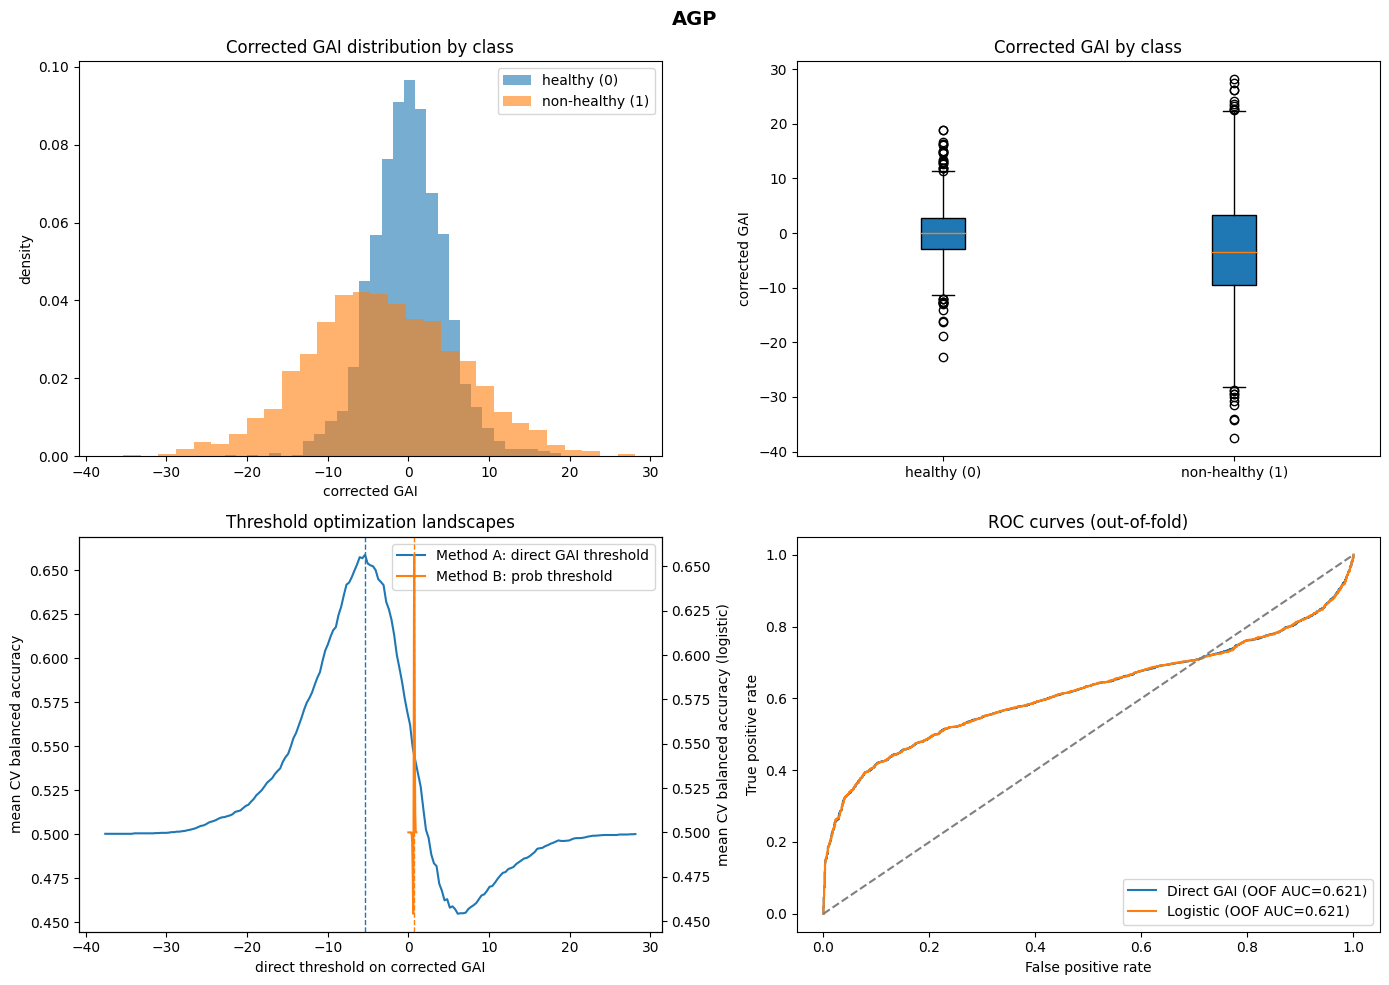


  AGP-agefix
Rows total: 5965  |  Rows used: 5965  |  Dropped: 0

Corrected GAI summary by class:
                 count  mean    median   std    min    max
healthy (0)       1852  0.00 -2.60e-03  4.49 -22.77  18.91
non-healthy (1)   4113 -2.72 -2.72e+00  9.14 -37.56  28.14

Mann-Whitney U = 3016585.00, p = 6.578e-38, rank-biserial = -0.2080

Method comparison (5-fold stratified CV):
                      method  best_threshold  balanced_accuracy_mean  balanced_accuracy_std  auc_mean  auc_std  sensitivity_mean  specificity_mean
     A: direct GAI threshold           -5.37                    0.65                   0.01       0.6     0.03              0.39               0.9
B: logistic + prob threshold            0.72                    0.65                   0.01       0.6     0.03              0.39               0.9

Best: A: direct GAI threshold | BA=0.6474 ± 0.0133 | AUC=0.6039 ± 0.0289  (below paper baseline 0.67)
Implied corrected GAI cutoff (logistic): -5.2883


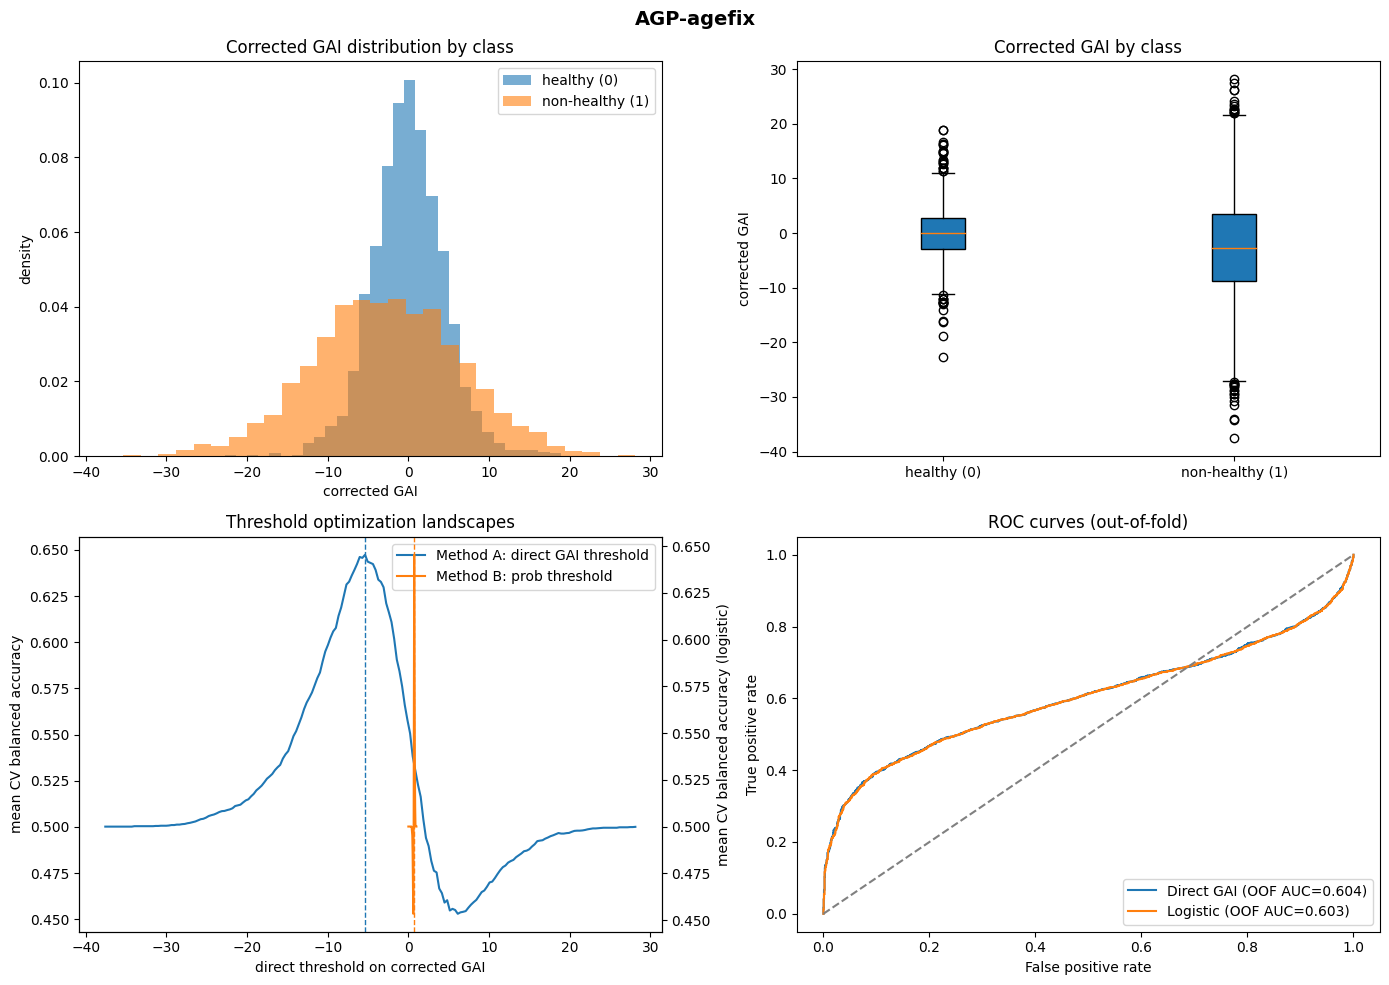


  GGMP
Rows total: 6242  |  Rows used: 5799  |  Dropped: 443

Corrected GAI summary by class:
                 count  mean  median    std    min    max
healthy (0)       1082  0.00   -0.04   3.48 -12.28  14.43
non-healthy (1)   4717 -5.81   -5.82  11.33 -48.97  38.78

Mann-Whitney U = 1604444.00, p = 3.996e-81, rank-biserial = -0.3713

Method comparison (5-fold stratified CV):
                      method  best_threshold  balanced_accuracy_mean  balanced_accuracy_std  auc_mean  auc_std  sensitivity_mean  specificity_mean
     A: direct GAI threshold           -5.53                    0.73               7.61e-03      0.69     0.01              0.51              0.95
B: logistic + prob threshold            0.83                    0.73               6.03e-03      0.69     0.01              0.51              0.95

Best: A: direct GAI threshold | BA=0.7298 ± 0.0076 | AUC=0.6856 ± 0.0121  (above paper baseline 0.67)
Implied corrected GAI cutoff (logistic): -5.4086


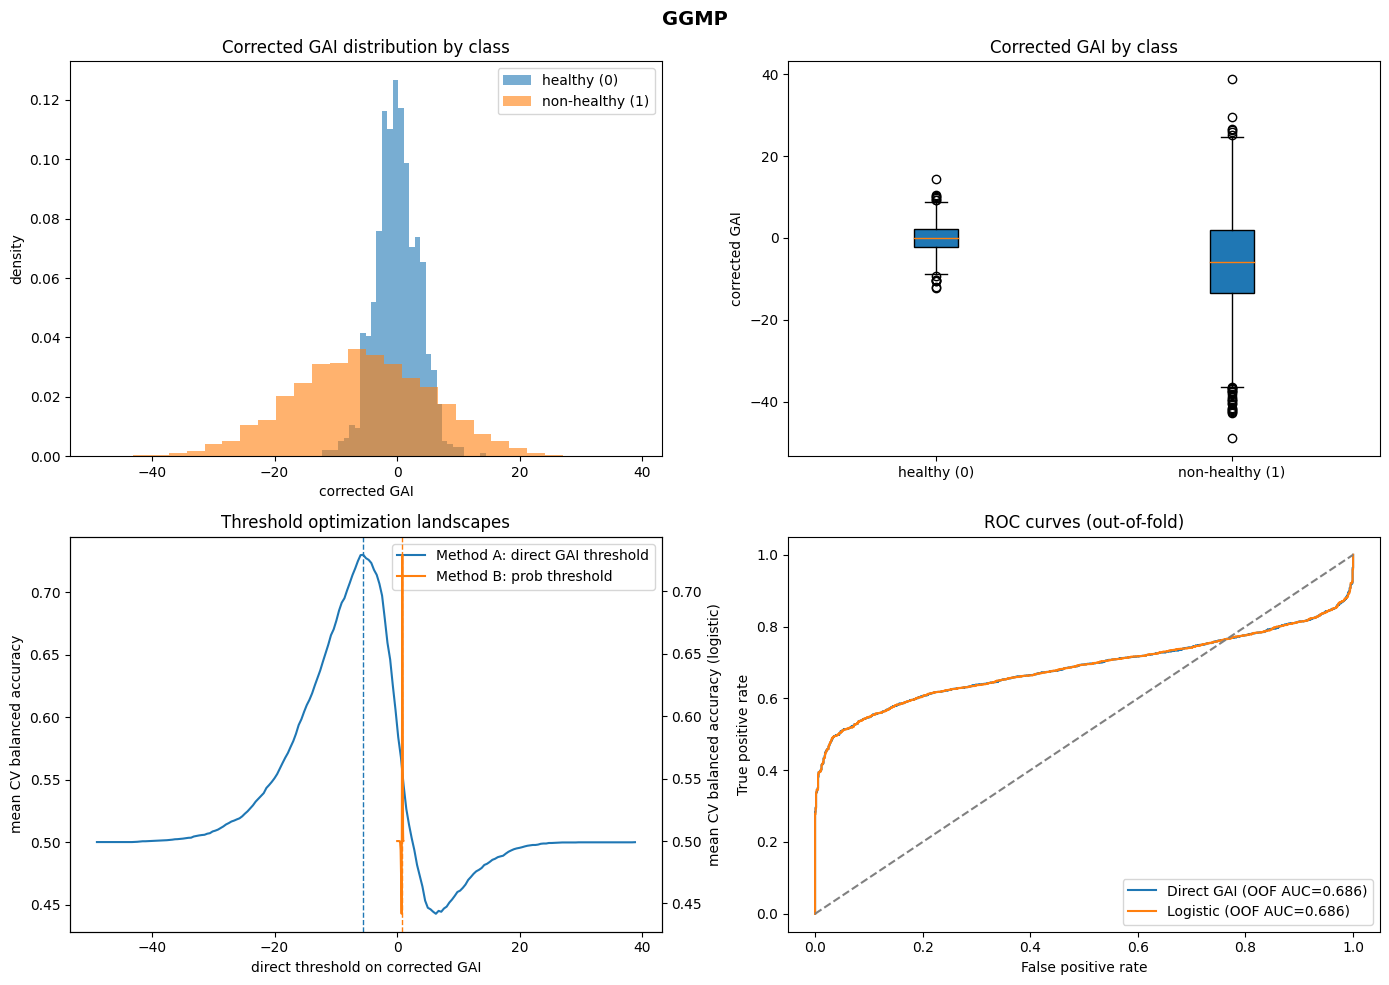


  GGMP-agefix
Rows total: 6242  |  Rows used: 6242  |  Dropped: 0

Corrected GAI summary by class:
                 count  mean  median    std    min    max
healthy (0)       1178  0.00   -0.03   3.44 -12.28  14.43
non-healthy (1)   5064 -5.31   -5.07  11.20 -48.97  38.78

Mann-Whitney U = 1979255.00, p = 1.564e-72, rank-biserial = -0.3364

Method comparison (5-fold stratified CV):
                      method  best_threshold  balanced_accuracy_mean  balanced_accuracy_std  auc_mean  auc_std  sensitivity_mean  specificity_mean
B: logistic + prob threshold            0.83                    0.72               7.26e-03      0.67 6.37e-03              0.48              0.95
     A: direct GAI threshold           -5.53                    0.72               7.62e-03      0.67 6.37e-03              0.48              0.95

Best: B: logistic + prob threshold | BA=0.7170 ± 0.0073 | AUC=0.6684 ± 0.0064  (above paper baseline 0.67)
Implied corrected GAI cutoff (logistic): -5.5743


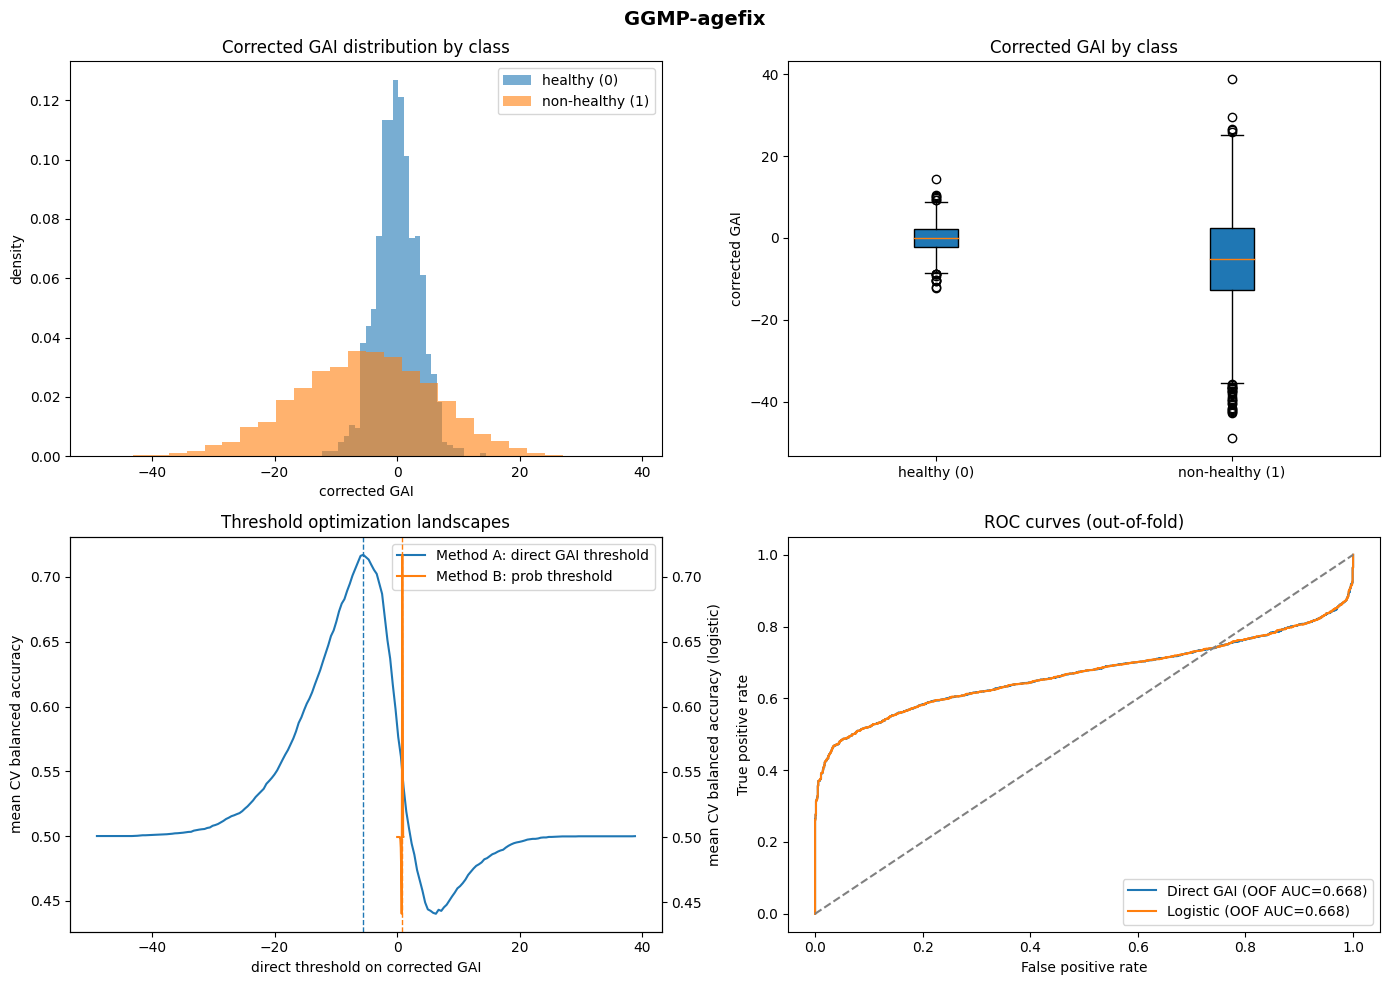

In [37]:
all_results = {}
paper_baseline = 0.67

for folder in output_dirs:
    print("=" * 70)
    print(f"  {folder}")
    print("=" * 70)

    res = analyse_folder(folder, output_root)
    all_results[folder] = res

    print(f"Rows total: {res['n_total']}  |  Rows used: {res['n_used']}  |  Dropped: {res['n_total'] - res['n_used']}")
    print(f"\nCorrected GAI summary by class:")
    print(res["summary"].round(4))
    print(f"\nMann-Whitney U = {res['u_stat']:.2f}, p = {res['p_value']:.3e}, rank-biserial = {res['rank_biserial']:.4f}")

    print(f"\nMethod comparison (5-fold stratified CV):")
    print(res["comparison_df"].to_string(index=False))

    winner = res["comparison_df"].iloc[0]
    status = "above" if winner["balanced_accuracy_mean"] > paper_baseline else "below"
    print(
        f"\nBest: {winner['method']} | "
        f"BA={winner['balanced_accuracy_mean']:.4f} ± {winner['balanced_accuracy_std']:.4f} | "
        f"AUC={winner['auc_mean']:.4f} ± {winner['auc_std']:.4f}  "
        f"({status} paper baseline {paper_baseline})"
    )

    # Implied GAI cutoff for logistic model
    mc = float(np.mean(res["coef_vals"]))
    mi = float(np.mean(res["intercept_vals"]))
    bt = res["best_thr_prob"]
    if abs(mc) > 1e-10 and 0 < bt < 1:
        implied = (np.log(bt / (1 - bt)) - mi) / mc
        print(f"Implied corrected GAI cutoff (logistic): {implied:.4f}")

    plot_results(res)
    print()

## Cross-dataset comparison

Side-by-side summary of the best method from each folder, plus a note on missing values.

In [38]:
cross_rows = []
for name, res in all_results.items():
    w = res["comparison_df"].iloc[0]
    cross_rows.append({
        "folder": name,
        "n_total": res["n_total"],
        "n_used": res["n_used"],
        "best_method": w["method"],
        "balanced_accuracy": w["balanced_accuracy_mean"],
        "auc": w["auc_mean"],
        "sensitivity": w["sensitivity_mean"],
        "specificity": w["specificity_mean"],
    })

cross_df = pd.DataFrame(cross_rows)
cross_df

,folder,n_total,n_used,best_method,balanced_accuracy,auc,sensitivity,specificity
0,AGP,5965,5350,A: direct GAI threshold,0.66,0.62,0.42,0.90
1,AGP-agefix,5965,5965,A: direct GAI threshold,0.65,0.60,0.39,0.90
2,GGMP,6242,5799,A: direct GAI threshold,0.73,0.69,0.51,0.95
3,GGMP-agefix,6242,6242,B: logistic + prob threshold,0.72,0.67,0.48,0.95


**Note:** Missing corrected GAI values (rows dropped) in non-agefix folders are due to the known missing [40, 45) age bin in `gai_cal.py`. The *-agefix* folders should show fewer dropped rows once that bug is patched.